## 任务 1：大数定律实验

In [23]:
import numpy as np

rng = np.random.default_rng(44)

def roller(N):
    rolls = rng.integers(1, 7, size=N)
    freq = np.bincount(rolls, minlength=7)[1:] / N
    dev = np.max(np.abs(freq - 1/6))
    return dev

print(10,roller(10))
print(100,roller(100))
print(10000,roller(10000))
print(1000000,roller(1000000))

10 0.13333333333333333
100 0.06333333333333335
10000 0.004266666666666669
1000000 0.0005443333333333411


## 任务 2：dice 的期望

In [28]:
import numpy as np

rng = np.random.default_rng(44)

rolls = rng.integers(1, 7, size=1000000)
print(rolls.mean())

3.50192


## 任务 1：离散→连续的桥

[4 3 5 ... 3 1 5] 
 [0 1 2 3 4 5 6 7 8 9] 
 [ 2855 11994 23293 26792 20058 10214  3725   909   145    15     0]
[2.82475249e-02 1.21060821e-01 2.33474440e-01 2.66827932e-01
 2.00120949e-01 1.02919345e-01 3.67569090e-02 9.00169200e-03
 1.44670050e-03 1.37781000e-04 5.90490000e-06]
[-3.024751e-04  1.120821e-03  5.444405e-04 -1.092068e-03 -4.590510e-04
  7.793452e-04 -4.930910e-04 -8.830800e-05 -3.299500e-06 -1.221900e-05
  5.904900e-06]


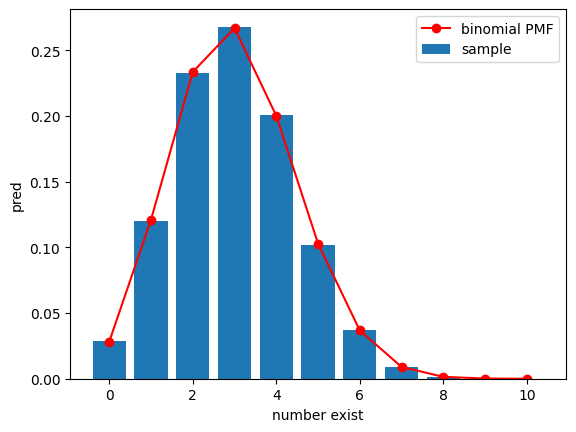

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

rng  = np.random.default_rng(42)

ks = np.arange(11)

bin = rng.binomial(n=10, p=0.3, size=100000)
list_ = np.unique(bin)
pred = np.bincount(bin, minlength=11)
plt.xlabel("number exist")
plt.ylabel("pred")
print(bin,"\n",list_,"\n",pred)

def PMF(n, p):
    #P(X=k)=C(N,k)·0.3^k·0.7^(10-k)
    pmf = np.array([math.comb(n, int(k)) for k in ks]) * p**ks * (1-p)**(n-ks)
    return pmf

print(PMF(10, 0.3))
print(PMF(10, 0.3) - pred/100000)

def poisson_PMF(k, lam):
    pmf = lam**k / math.factorial(k) * math.e**(-lam)
    return pmf

#对比
poisson_like = PMF(100, 0.3)
poisson = poisson_PMF(100, 3)

plt.bar(ks, pred/100000, label='sample')
plt.plot(ks, PMF(10,0.3), 'ro-', label='binomial PMF')
plt.legend(); plt.show()

## 任务 2：正态分布 + CLT 初体验

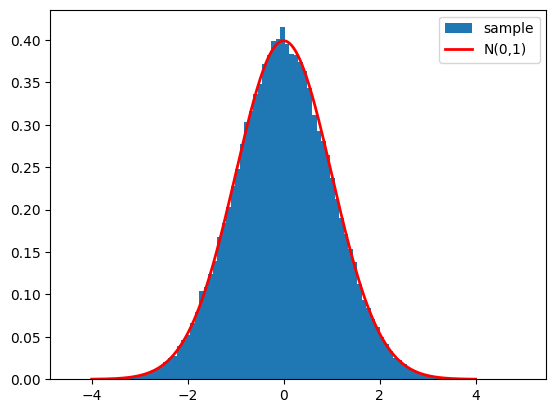

面积 = 1.0000000000000002
实验均值 = 5.998616468015908  理论 = 6
实验方差 = 0.9975535878175518  理论 = 1


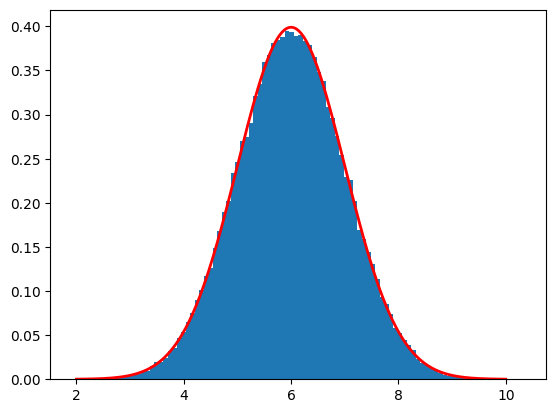

实验 std(m12) = 0.08323133707297524 理论 1/√12/√12 = 0.08333333333333334


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import math

# 设置随机数生成器（可自行修改种子）
rng = np.random.default_rng(seed=42)

# ===== 任务2a：正态密度 =====
samples = rng.standard_normal(100000)
x = np.linspace(-4, 4, 400)                     # ← 横轴范围：±4σ
theory = np.exp(-x**2/2) / np.sqrt(2 * np.pi)   # ← 完整常数 √(2π)

plt.hist(samples, bins=100, density=True, label='sample')   # ← bins=100, density=True
plt.plot(x, theory, 'r-', lw=2, label='N(0,1)')
plt.legend()
plt.show()

# 自检1：面积
counts, edges = np.histogram(samples, bins=100, density=True)  # ← bins, density
print('面积 =', np.sum(counts * np.diff(edges)))                # ← 条宽×密度求和，应≈1

# ===== 任务2b：12 均匀之和 → 正态 =====
U = rng.uniform(0, 1, (100000, 12))          # ← 100000 行，12 列
s12 = U.sum(axis=1)                          # ← 对 axis=1 求和

plt.hist(s12, bins=100, density=True)
x2 = np.linspace(2, 10, 400)                # ← 覆盖 μ±4σ，μ=6, σ=1
print('实验均值 =', np.mean(s12), ' 理论 =', 6)          # ← 理论均值 12×0.5=6
print('实验方差 =', np.var(s12), ' 理论 =', 1)          # ← 理论方差 12×(1/12)=1

# 对照 N(6, 1) 密度
theory2 = np.exp(-(x2-6)**2/(2*1)) / np.sqrt(2*np.pi*1)   # ← μ=6, σ²=1
plt.plot(x2, theory2, 'r-', lw=2)
plt.show()

# ===== 任务2c：验证 1/√n =====
m12 = s12 / 12                              # ← 12个均匀的平均
print('实验 std(m12) =', np.std(m12), '理论 1/√12/√12 =', 1/np.sqrt(12)/np.sqrt(12))